In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install ta
#uncomment for "ta" installation

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29482 sha256=66fd1fe63e6407a5dc4a57787b30ccf1d0b7e254336dc13a7f275a66c49c21d7
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import ta

#past 5 years data for initial stage(if not enough we will run more longer)

tickers = ["NVDA", "MSFT", "CVX" , "GE", "BRK-B" ]
dfs = {t: yf.Ticker(t).history(period="max") for t in tickers}


def add_indicators(df):
    # Moving Averages
    df["SMA_50"] = ta.trend.sma_indicator(df["Close"], window=50)
    df["SMA_200"] = ta.trend.sma_indicator(df["Close"], window=200)
    df["EMA_50"] = ta.trend.ema_indicator(df["Close"], window=50)
    df["EMA_200"] = ta.trend.ema_indicator(df["Close"], window=200)

    # RSI
    df["RSI"] = ta.momentum.rsi(df["Close"], window=14)

    # MACD
    df["MACD"] = ta.trend.macd(df["Close"])
    df["MACD_Signal"] = ta.trend.macd_signal(df["Close"])
    df["MACD_Hist"] = df["MACD"] - df["MACD_Signal"]

    # Bollinger Bands
    df["BB_Upper"] = ta.volatility.bollinger_hband(df["Close"], window=20)
    df["BB_Middle"] = ta.volatility.bollinger_mavg(df["Close"], window=20)
    df["BB_Lower"] = ta.volatility.bollinger_lband(df["Close"], window=20)

    # ATR
    df["ATR"] = ta.volatility.average_true_range(df["High"], df["Low"], df["Close"], window=14)

    # ADX
    df["ADX"] = ta.trend.adx(df["High"], df["Low"], df["Close"], window=14)

    return df

for t in tickers:
    dfs[t] = add_indicators(dfs[t])

for t in tickers:
    print(f"\n--- {t} ---")
    print(dfs[t].tail())


--- NVDA ---
                                 Open        High         Low       Close  \
Date                                                                        
2026-08-11 00:00:00-04:00  222.169998  222.199997  216.199997  217.500000   
2026-08-12 00:00:00-04:00  221.039993  225.100006  220.199997  224.089996   
2026-08-13 00:00:00-04:00  225.059998  227.229996  223.710007  225.300003   
2026-08-14 00:00:00-04:00  226.770004  227.490005  224.500000  225.160004   
2026-08-17 00:00:00-04:00         NaN         NaN         NaN         NaN   

                              Volume  Dividends  Stock Splits      SMA_50  \
Date                                                                        
2026-08-11 00:00:00-04:00  101273100        0.0           0.0  206.251788   
2026-08-12 00:00:00-04:00  108783600        0.0           0.0  206.251611   
2026-08-13 00:00:00-04:00   98867200        0.0           0.0  206.306399   
2026-08-14 00:00:00-04:00   75680900        0.0           0.0

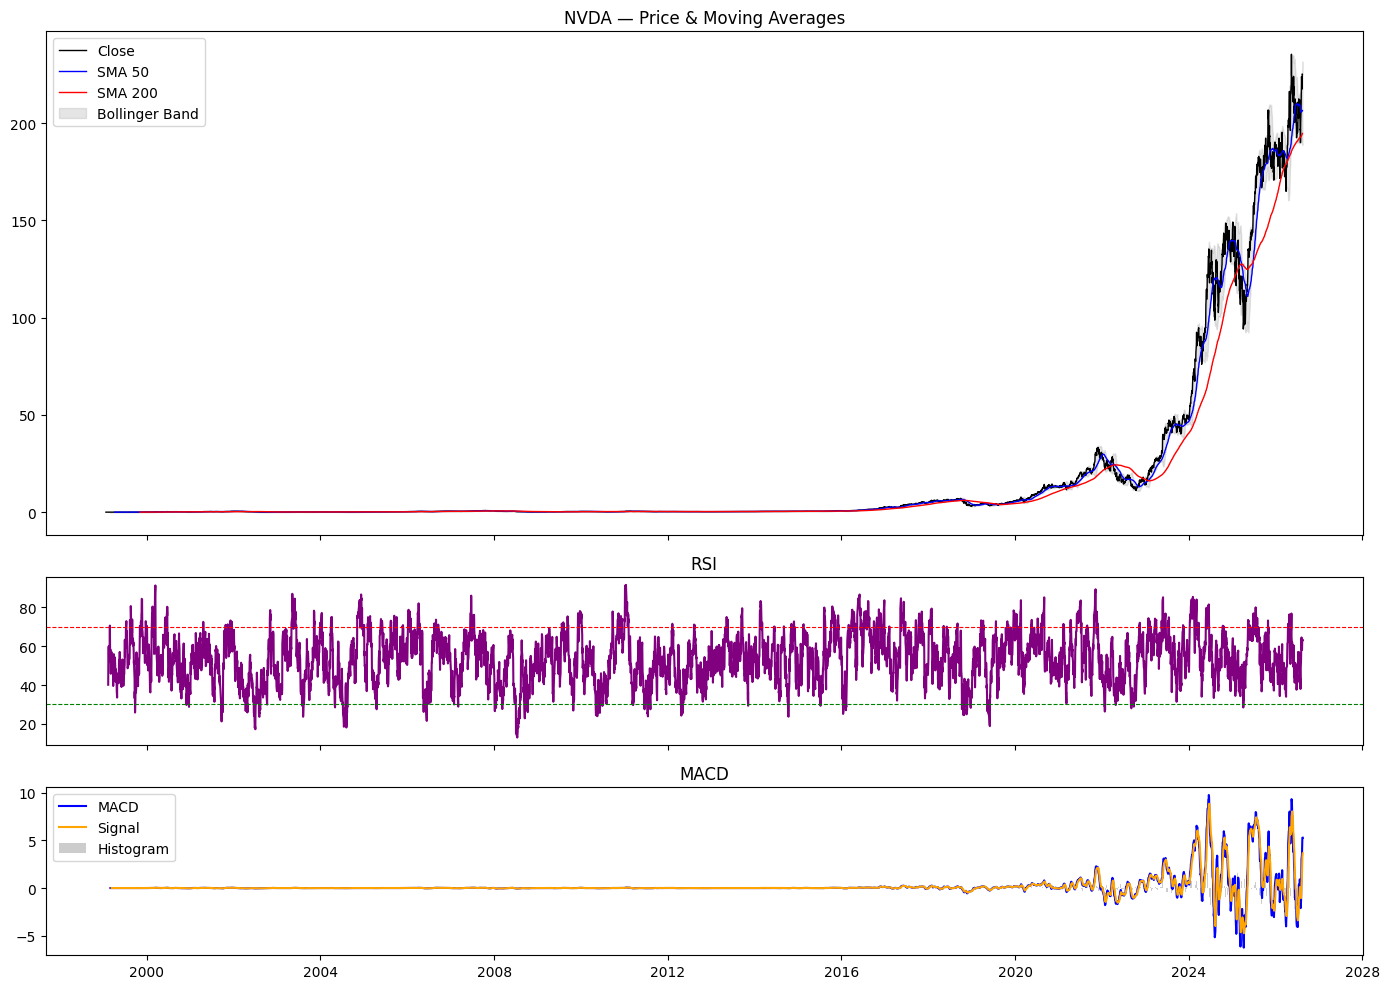

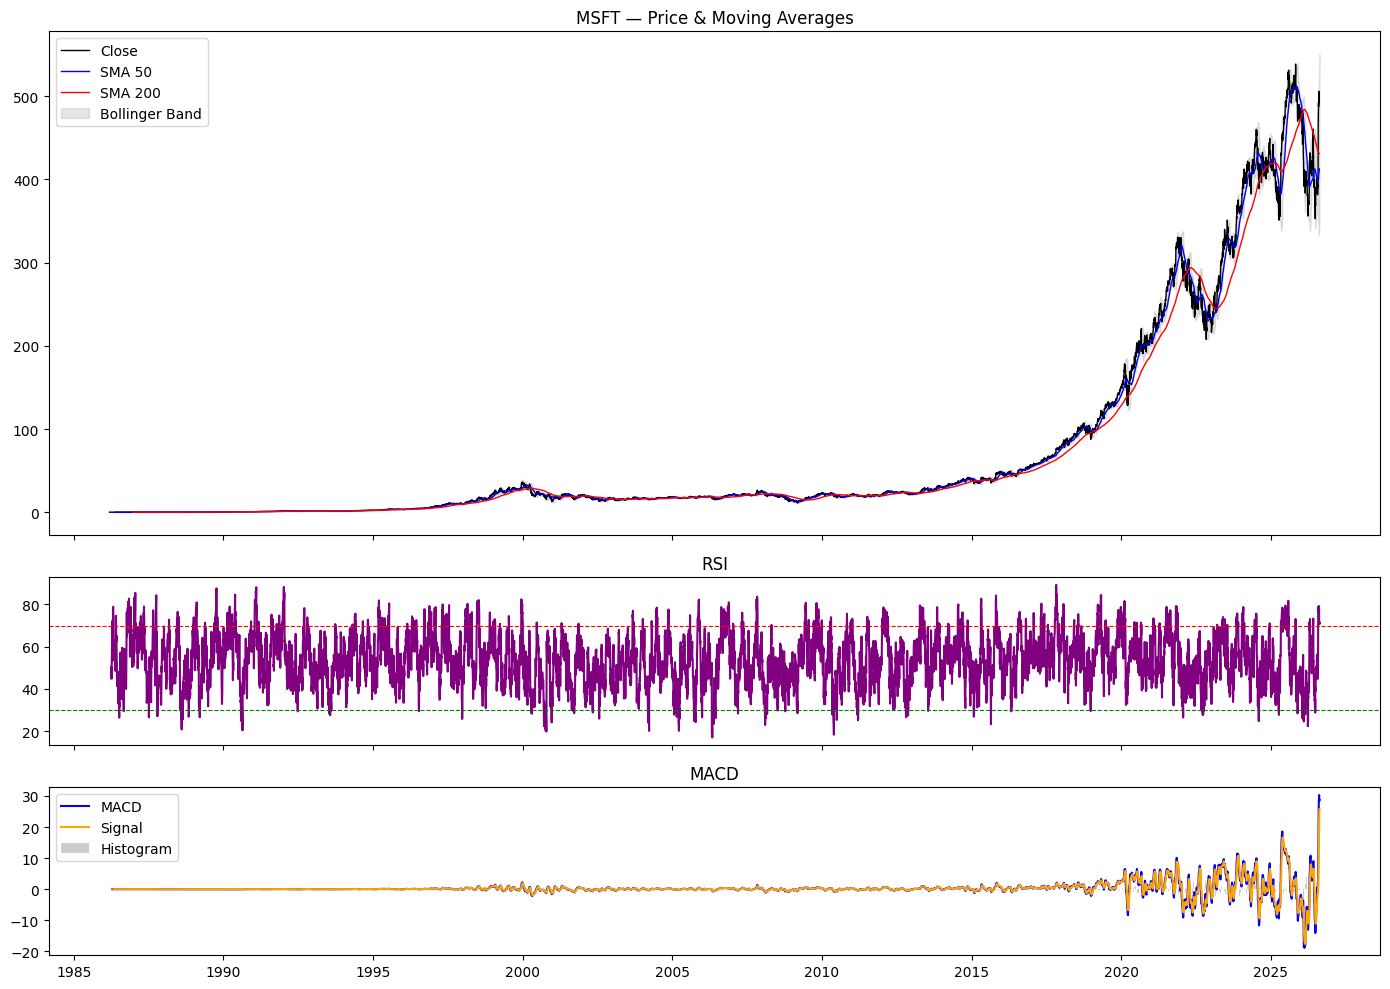

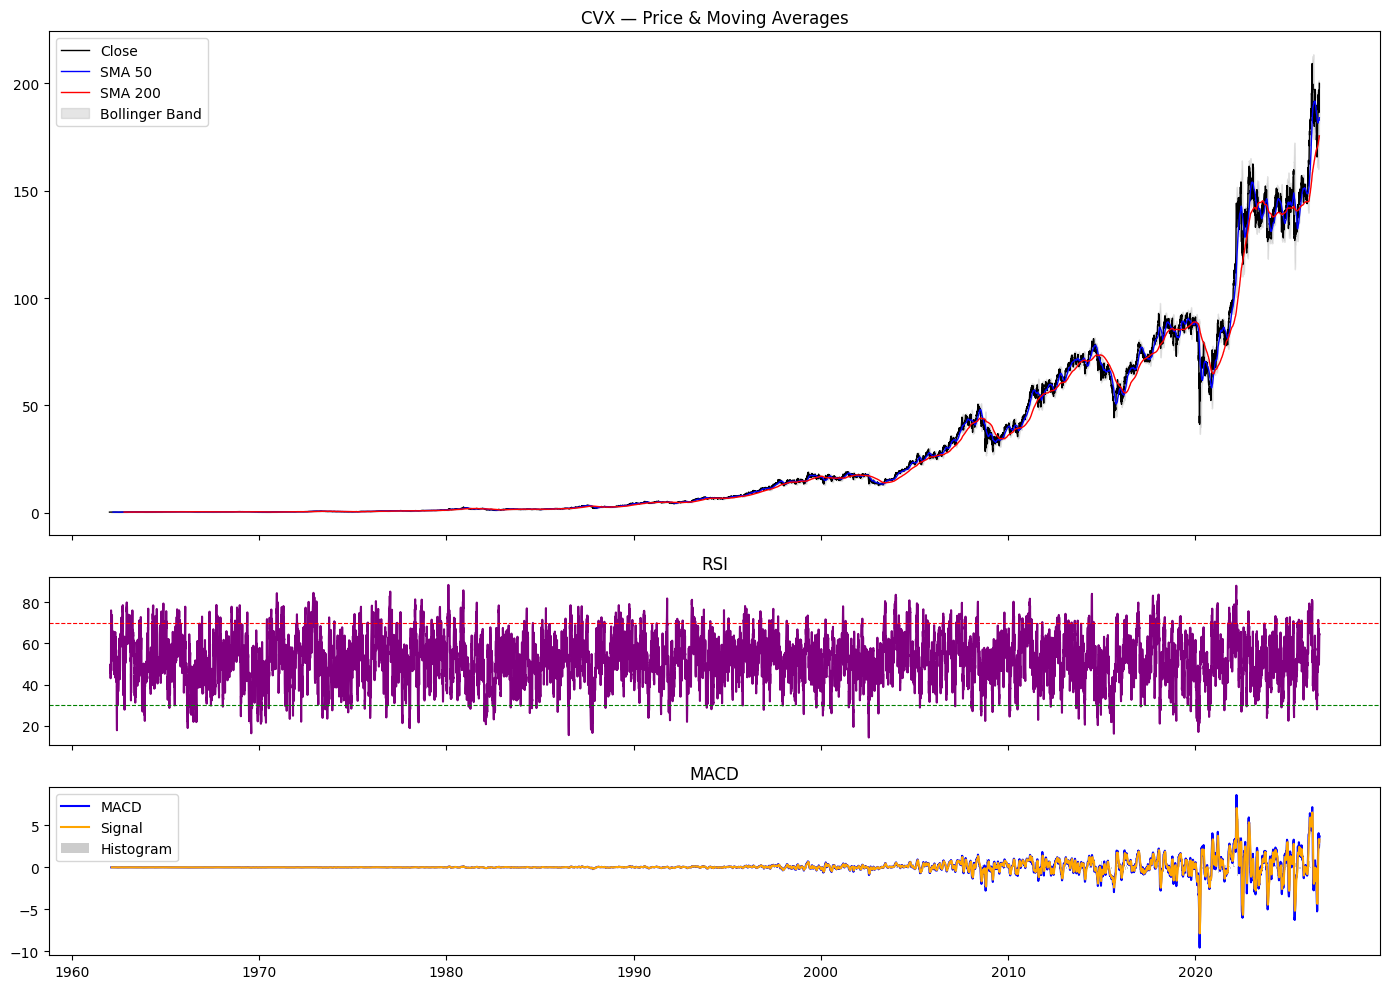

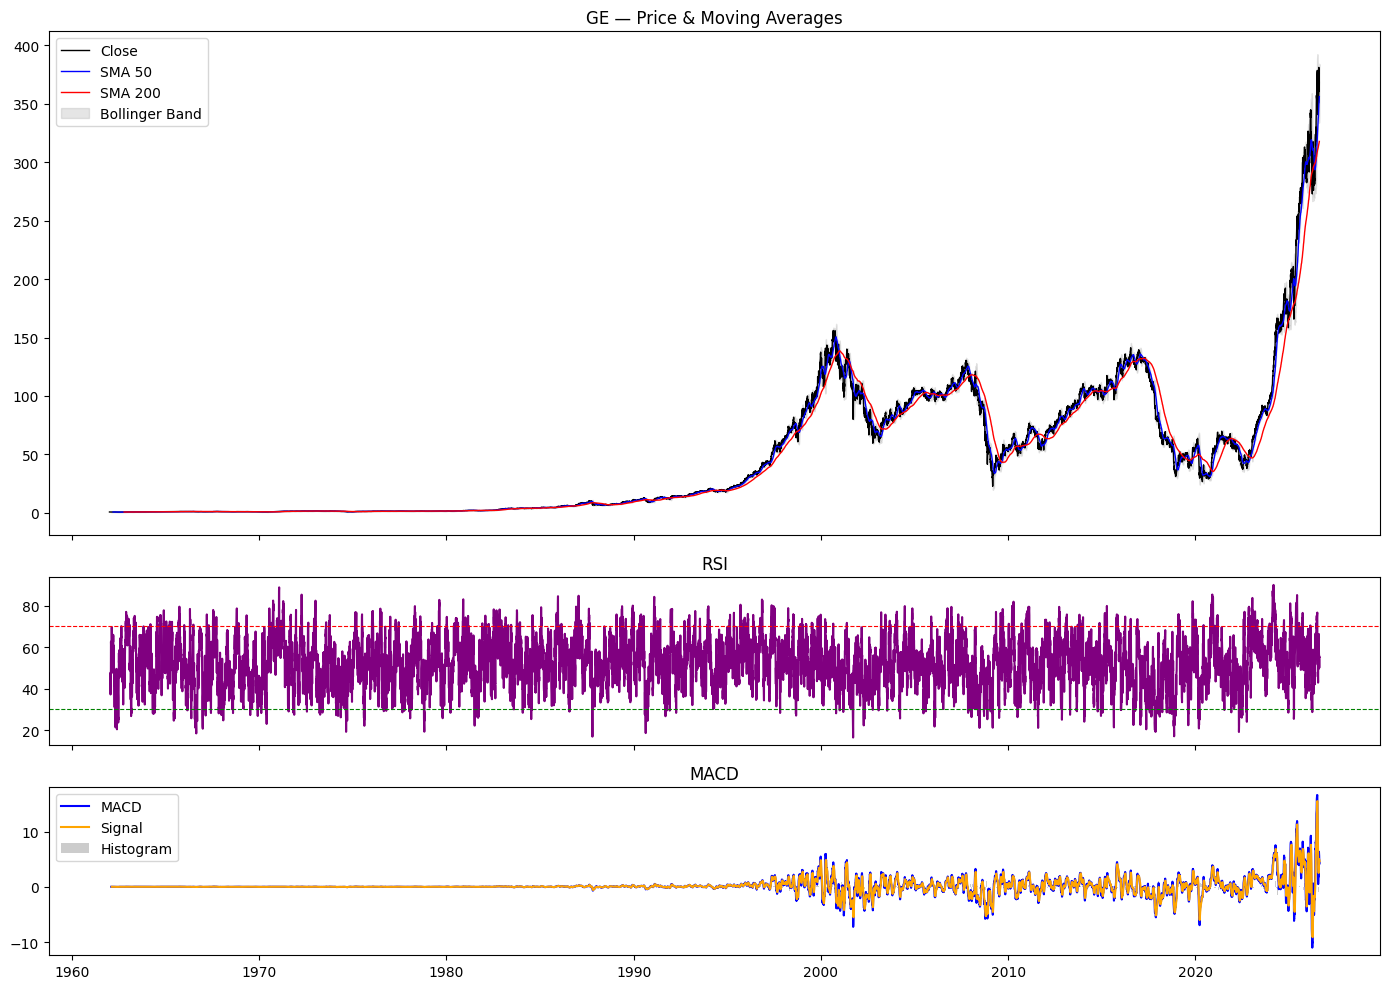

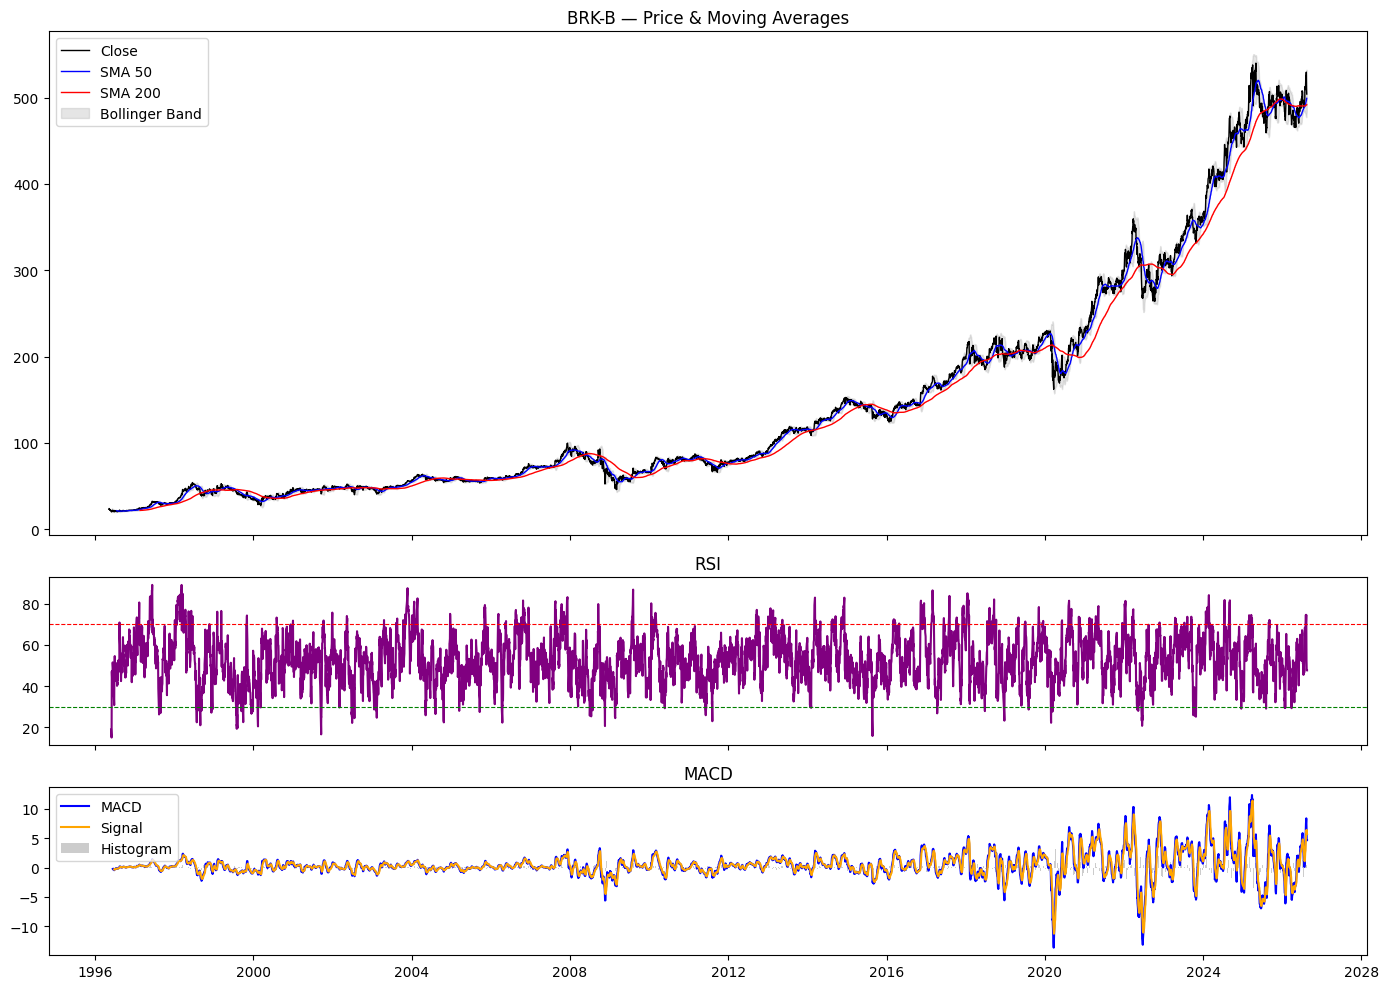

In [4]:
import matplotlib.pyplot as plt

def plot_stock(df, ticker):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1, 1]})

    # Price + Moving Averages + Bollinger Bands
    axes[0].plot(df.index, df["Close"], label="Close", color="black", linewidth=1)
    axes[0].plot(df.index, df["SMA_50"], label="SMA 50", color="blue", linewidth=1)
    axes[0].plot(df.index, df["SMA_200"], label="SMA 200", color="red", linewidth=1)
    axes[0].fill_between(df.index, df["BB_Upper"], df["BB_Lower"], color="grey", alpha=0.2, label="Bollinger Band")
    axes[0].set_title(f"{ticker} — Price & Moving Averages")
    axes[0].legend(loc="upper left")

    # RSI
    axes[1].plot(df.index, df["RSI"], color="purple")
    axes[1].axhline(70, color="red", linestyle="--", linewidth=0.8)
    axes[1].axhline(30, color="green", linestyle="--", linewidth=0.8)
    axes[1].set_title("RSI")

    # MACD
    axes[2].plot(df.index, df["MACD"], label="MACD", color="blue")
    axes[2].plot(df.index, df["MACD_Signal"], label="Signal", color="orange")
    axes[2].bar(df.index, df["MACD_Hist"], label="Histogram", color="grey", alpha=0.4)
    axes[2].set_title("MACD")
    axes[2].legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# Plot one ticker
# plot_stock(dfs["NVDA"], "NVDA")

for t in tickers:
    plot_stock(dfs[t], t)

In [5]:
import os
import pandas as pd

os.makedirs("stock_data_output", exist_ok=True)

combined = pd.concat(dfs, names=["Ticker", "Date"])
combined.to_csv("stock_data_output/all_tickers_combined.csv")

# Data Summary
# ------------
# Source: yfinance (Ticker.history, period="max")
# Coverage: 1996–2026 (~30 years), varies slightly by ticker based on IPO/listing date
# Tickers: NVDA, MSFT, CVX, GE, BRK-B
# Frequency: Daily OHLCV + technical indicators (SMA, EMA, RSI, MACD, Bollinger Bands, ATR, ADX)

In [6]:
df_combined = pd.read_csv(
    "/kaggle/working/stock_data_output/all_tickers_combined.csv",
    index_col=[0, 1],
    parse_dates=[1]
)

dfs_check = {}

for t in tickers:
    df = df_combined.loc[t]
    dfs_check[t] = df
    print(f"{t}: starts {df.index.min().date()}, ends {df.index.max().date()} — {len(df)} rows")

NVDA: starts 1999-01-22, ends 2026-08-17 — 6934 rows
MSFT: starts 1986-03-13, ends 2026-08-17 — 10185 rows
CVX: starts 1962-01-02, ends 2026-08-17 — 16264 rows
GE: starts 1962-01-02, ends 2026-08-17 — 16264 rows
BRK-B: starts 1996-05-09, ends 2026-08-17 — 7616 rows


In [7]:
start_date = "2020-01-01"
end_date = "2025-12-31"

dfs_filtered = {}

for t in tickers:
    df = dfs_check[t].copy()
    df.index = pd.to_datetime(df.index, utc=True)  # force to one common timezone

    mask = (df.index >= pd.Timestamp(start_date, tz="UTC")) & (df.index <= pd.Timestamp(end_date, tz="UTC"))
    filtered = df[mask]

    dfs_filtered[t] = filtered
    print(f"{t}: starts {filtered.index.min().date()}, ends {filtered.index.max().date()} — {len(filtered)} rows")

NVDA: starts 2020-01-02, ends 2025-12-30 — 1507 rows
MSFT: starts 2020-01-02, ends 2025-12-30 — 1507 rows
CVX: starts 2020-01-02, ends 2025-12-30 — 1507 rows
GE: starts 2020-01-02, ends 2025-12-30 — 1507 rows
BRK-B: starts 2020-01-02, ends 2025-12-30 — 1507 rows


## Observation

**Date range checked:** 2020-01-01 to 2025-12-31
**Expected trading days:** ~1507–1510 (US market, excluding weekends/holidays)

### Results

| Ticker | Start Date | End Date | Row Count |
|--------|------------|------------|-----------|
| NVDA   | 2020-01-02 | 2025-12-30 | 1507      |
| MSFT   | 2020-01-02 | 2025-12-30 | 1507      |
| CVX    | 2020-01-02 | 2025-12-30 | 1507      |
| GE     | 2020-01-02 | 2025-12-30 | 1507      |
| BRK-B  | 2020-01-02 | 2025-12-30 | 1507      |

### Conclusion

All 5 stocks match exactly — same start date, same end date, same row count.
This confirms the data is aligned and safe to merge or combine for further analysis
(e.g. joining sentiment data, building a combined feature table across stocks).

In [8]:
os.makedirs("stock_data_2020_2025", exist_ok=True)

combined_filtered = {}

for t in tickers:
    df = dfs_filtered[t].copy()
    df.index = df.index.tz_localize(None)  # remove timezone, avoids future merge errors
    df["date_only"] = df.index.date         # clean join key for merging with news later
    combined_filtered[t] = df

combined_df = pd.concat(combined_filtered, names=["Ticker", "Date"])
combined_df.to_csv("stock_data_2020_2025/all_tickers_2020_2025.csv")

print("Saved: all_tickers_2020_2025.csv")

Saved: all_tickers_2020_2025.csv


## Conclusion

This phase of the project focused on collecting and preparing historical price data for 5 stocks (NVDA, MSFT, CVX, GE, BRK-B), to serve as the foundation for the upcoming sentiment analysis project.

### Steps Completed

1. **Data Collection** — Downloaded full historical price data (Open, High, Low, Close, Volume) for all 5 tickers using `yfinance`.
2. **Technical Indicators** — Calculated a full set of indicators for each stock, including:
   - Moving Averages (SMA 50/200, EMA 50/200)
   - RSI (14-day)
   - MACD (MACD, Signal, Histogram)
   - Bollinger Bands (Upper, Middle, Lower)
   - ATR (14-day)
   - ADX (14-day)
3. **Date Alignment Check** — Verified all 5 stocks share identical trading dates with no missing days, confirming the data is safe to combine.
4. **Date Filtering** — Narrowed the dataset to a fixed window: **2020-01-02 to 2025-12-30** (1507 trading days per stock), since indicators were calculated first on full history to avoid incomplete warm-up values at the start of the window.
5. **Final Output** — Saved one combined CSV (`all_tickers_2020_2025.csv`) with a clean `date_only` column, ready to be joined with future news/sentiment data.

### Why This Matters

Having clean, aligned, and verified price data is an important first step before adding sentiment analysis. Since all 5 stocks now share the same date range and the same row structure, merging future news sentiment scores by date will be simple and reliable — no mismatched dates, no missing days, no timezone conflicts.

### Next Steps

- Collect News Tone via GDELT with "TimelineTone" provided by GDELT.
- Merge sentiment scores into this price dataset using the `date_only` column as the shared key
- Build the prediction model combining price/technical indicators with sentiment features